In [1]:
import os, sys
sys.path.append('../scripts')

from peak_tester import EmissionsPeakTest
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_indexing as pix
from pandas_indexing import *

import joblib

from helper_functions import HiddenPrints, segment_by_peaks

In [2]:
G20_ISOS = ['AUS','ARG','BRA','CAN','CHN','EU27','IND','IDN','JPN','MEX','RUS','SAU','KOR','TUR','GBR','USA','ZAF'] 
short_ISOS = ['AUS', 'CHN', 'GBR']

In [3]:
# Collect data

em_data = dict()
ci_data = dict()
ei_data = dict()
gdp_data = dict()

for iso in short_ISOS:
    with HiddenPrints():
        peak_tester_iso = EmissionsPeakTest()
        peak_tester_iso.load_historical_data(
            'gcb_hist_co2.csv', region=iso, year_range=range(1990, 2025))
        em_data[iso] = peak_tester_iso.historical_data
        peak_tester_iso.load_historical_data(
            'carbon_intensity_energy.csv', region=iso, year_range=range(1990, 2025))
        ci_data[iso] = peak_tester_iso.historical_data
        peak_tester_iso.load_historical_data(
            'energy_intensity_gdp.csv', region=iso, year_range=range(1990, 2025))
        ei_data[iso] = peak_tester_iso.historical_data
        peak_tester_iso.load_historical_data(
            'wdi_gdp.csv', region=iso, year_range=range(1990, 2025))
        gdp_data[iso] = peak_tester_iso.historical_data


        

###
TODO: Add function to add later yars of data as estimates?

In [4]:
# collect LMDI analysis 

def perform_lmdi_decomposition(country, gdp_data, ei_data, ci_data, em_data):
    results = []
    for year in em_data[country].index[1:]:  # Start from second year to have a base year
        # Get values for base year (t-1) and current year (t)
        A0, A1 = gdp_data[country].loc[year-1, 'emissions'], gdp_data[country].loc[year, 'emissions']
        I0, I1 = ei_data[country].loc[year-1, 'emissions'], ei_data[country].loc[year, 'emissions']
        C0, C1 = ci_data[country].loc[year-1, 'emissions'], ci_data[country].loc[year, 'emissions']
        E0, E1 = em_data[country].loc[year-1, 'emissions'], em_data[country].loc[year, 'emissions']

        # # Check if current year data is estimated (TODO add in if we want to mark estimated data)
        # is_estimated_current = entity_data.loc[year, 'is_estimated'] if 'is_estimated' in entity_data.columns else False
        # is_estimated_previous = entity_data.loc[year-1, 'is_estimated'] if 'is_estimated' in entity_data.columns else False
        
        # Skip if any values are invalid
        if any(val <= 0 or np.isnan(val) for val in [A0, A1, I0, I1, C0, C1, E0, E1]):
            continue
        
        # Logarithmic mean for LMDI
        def log_mean(x, y):
            if abs(x - y) < 1e-10:
                return (x + y) / 2
            return (x - y) / (np.log(x) - np.log(y))
        
        L = log_mean(E1, E0)
        
        # LMDI decomposition effects
        activity_effect = L * np.log(A1 / A0)
        intensity_effect = L * np.log(I1 / I0)  
        carbon_effect = L * np.log(C1 / C0)
        
        total_change = E1 - E0
        computed_change = activity_effect + intensity_effect + carbon_effect
        
        results.append({
            'year': year,
            'activity_effect': activity_effect,
            'intensity_effect': intensity_effect,
            'carbon_effect': carbon_effect,
            'total_change': total_change,
            'computed_change': computed_change,
            'residual': total_change - computed_change,
            'activity_growth': (A1 / A0) - 1,
            'energy_intensity_change': (I1 / I0) - 1,
            'carbon_intensity_change': (C1 / C0) - 1,
            'emissions_change': (E1 / E0) - 1,
            'carbon_intensity': C1,
            'energy_intensity': E1,
            'decoupling_forces': intensity_effect + carbon_effect
            # 'is_estimated': is_estimated_current or is_estimated_previous  # Flag if either year is estimated
        })

    return pd.DataFrame(results)

In [5]:
peak_tester = EmissionsPeakTest()
lmdi_results = dict()
for country in short_ISOS:
        lmdi_results[country] = perform_lmdi_decomposition(country, gdp_data, ei_data, ci_data, em_data)

In [6]:
lmdi_results['AUS']

,year,activity_effect,intensity_effect,carbon_effect,total_change,computed_change,residual,activity_growth,energy_intensity_change,carbon_intensity_change,emissions_change,carbon_intensity,energy_intensity,decoupling_forces
0,1991,-1.067587,-1.368483,3.812429,1.376359,1.376359,-1.394440e-13,-0.003823,-0.004897,0.013771,0.004950,76.611833,279.437374,2.443945
1,1992,1.204890,3.188345,0.602848,4.996082,4.996082,-7.993606e-14,0.004283,0.011373,0.002141,0.017879,76.775828,284.433456,3.791192
2,1993,11.369457,-4.995854,-2.026627,4.346976,4.346976,9.592327e-14,0.040467,-0.017280,-0.007046,0.015283,76.234842,288.780433,-7.022481
3,1994,11.365771,-0.087063,-6.445847,4.832861,4.832861,-5.595524e-14,0.039804,-0.000299,-0.021893,0.016735,74.565833,293.613294,-6.532909
4,1995,11.408456,-3.382593,3.323141,11.349003,11.349003,-3.552714e-14,0.038859,-0.011240,0.011167,0.038653,75.398488,304.962297,-0.059452
5,1996,11.691546,-2.724131,-2.078824,6.888591,6.888591,2.113865e-13,0.038639,-0.008794,-0.006718,0.022588,74.891950,311.850888,-4.802955
6,1997,12.131121,-4.261808,0.522332,8.391646,8.391646,4.796163e-14,0.039132,-0.013395,0.001654,0.026909,75.015834,320.242533,-3.739475
7,1998,14.908030,-6.924078,5.811280,13.795232,13.795232,-3.410605e-13,0.046632,-0.020946,0.017925,0.043077,76.360514,334.037766,-1.112797
8,1999,16.625956,-2.958029,-3.829506,9.838421,9.838421,7.638334e-14,0.050277,-0.008689,-0.011235,0.029453,75.502595,343.876187,-6.787535
9,2000,13.342895,-11.319981,3.998554,6.021469,6.021469,-9.592327e-14,0.039215,-0.032107,0.011594,0.017511,76.377969,349.897655,-7.321427


In [9]:
def plot_lmdi_country(country, lmdi_results, figsize=(10, 8)):
    """Plot a single entity - easy to edit and test"""
    data = lmdi_results[country]
    
    fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=figsize, 
                                             sharex=True, 
                                             gridspec_kw={'height_ratios': [1, 2]})
    
    # Top panel: CO2 changes and carbon intensity
    bar_colors = ['darkgrey' if val < 0 else 'lightgrey' 
                  for val in data['total_change']]
    ax_top.bar(data['year'], data['total_change'], 
               color=bar_colors, alpha=0.6, width=0.8)
    
    ax_top2 = ax_top.twinx()
    ax_top2.plot(data['year'], data['carbon_intensity'],
                 label='Carbon intensity', linewidth=2, color='purple')
    ax_top2.set_ylabel('Carbon Intensity', color='purple')
    
    # Bottom panel: LMDI effects
    ax_bottom.plot(data['year'], data['activity_effect'], 
                   label='GDP', linewidth=2.5, color='deeppink')
    ax_bottom.plot(data['year'], data['intensity_effect'], 
                   label='Energy intensity (EI)', linewidth=1.5, color='lightgreen')
    ax_bottom.plot(data['year'], data['carbon_effect'], 
                   label='Carbon intensity (CI)', linewidth=1.5, color='turquoise')
    ax_bottom.plot(data['year'], data['decoupling_forces'], 
                   label='Decoupling effects (CI + EI)', linewidth=2.5, color='navy')
    
    ax_bottom.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax_bottom.legend(loc='best')
    ax_bottom.set_xlabel('Year')
    ax_bottom.set_ylabel('Effect (Mt CO2/yr)')
    ax_top.set_title(f'{entity_name}')
    
    plt.tight_layout()
    return fig

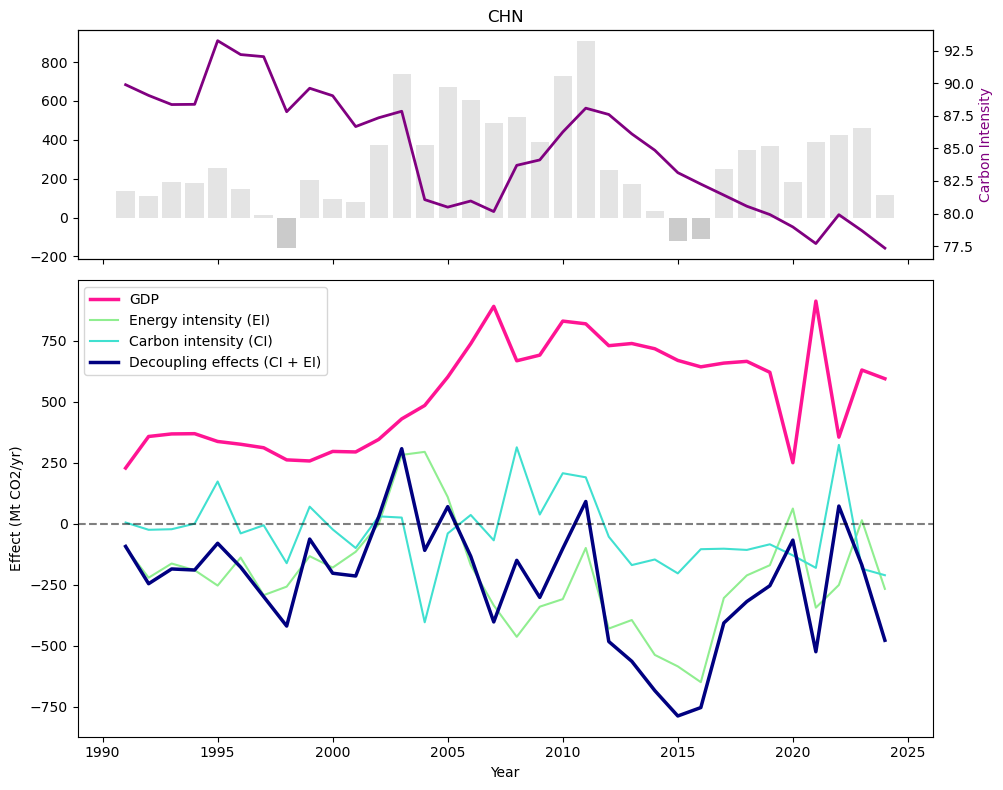

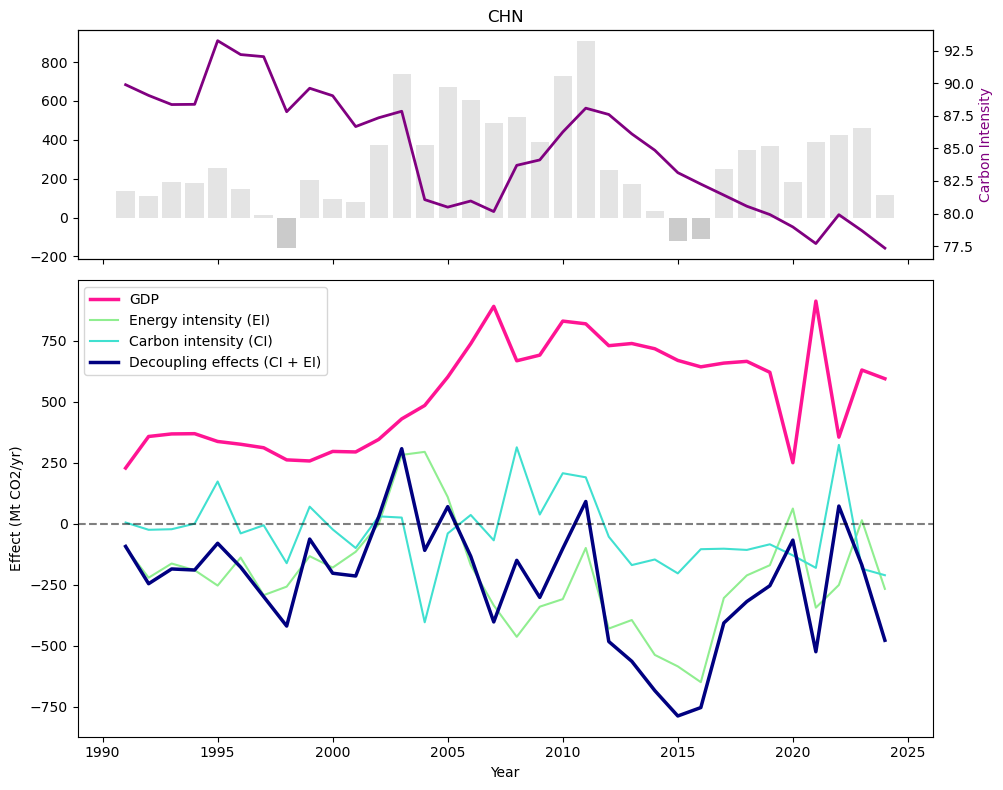

In [ ]:
plot_lmdi_country('CHN', lmdi_results)

In [ ]:
def plot_mulitple_countries(lmdi_results, countries=None, save_path = None):
    """Plot all entities in a grid

    args:
        lmdi_data (dict): Dictionary with entity names as keys and their LMDI data.
        # hist_data (dict): Dictionary with historical data (e.g., carbon intensity as function of GDP).
        countries (list, optional): List of country names to plot. If None, plot all

    """
    if countries is None:
        countries = list(lmdi_data.keys())
    
    n_entities = len(countries)
    cols = 3
    rows = (n_entities + cols - 1) // cols
    
    fig = plt.figure(figsize=(18, 6*rows))
    
    # Add overall title
    fig.suptitle('LMDI Decomposition Analysis', 
                 fontsize=16, 
                 fontweight='bold',
                 y=0.98)  # Adjust vertical position (0-1)
    
    for i, country in enumerate(countries):
        # Your grid plotting logic here
            # Create two subplots vertically stacked for each country
            ax_top = plt.subplot(rows * 2, cols, (i % cols) + 1 + (i // cols) * cols * 2)
            ax_bottom = plt.subplot(rows * 2, cols, (i % cols) + 1 + cols + (i // cols) * cols * 2, sharex=ax_top)
            data = lmdi_results[country]

            # Plot CO2 emission changes as grey bars
            if 'total_change' in data.columns:
                # Create bars with colors based on positive/negative values
                bar_colors = ['darkgrey' if val < 0 else 'lightgrey' 
                              for val in data['total_change']]
                bars = ax_top.bar(data['year'], data['total_change'], 
                             color=bar_colors, alpha=0.6, width=0.8, 
                             label='CO2 emissions change', zorder=2)
                
                # # Highlight bars that represent only data estimates differently - not used yet
                # if 'is_estimated' in data.columns:
                #     estimated_mask = data['is_estimated'] == True
                #     if estimated_mask.any():
                #         # Update color for estimated bars
                #         estimated_indices = data.index[estimated_mask].tolist()
                #         for idx in estimated_indices:
                #             if idx < len(bars):
                #                 bars[idx].set_color('darkgrey')
                #                 bars[idx].set_alpha(0.7)
                #                 bars[idx].set_edgecolor('black')
                #                 bars[idx].set_linewidth(1)
            
            ax_top.set_ylabel('CO2 Emissions Change (Mt CO2/yr)', fontsize=9)

            # plot carbon intensity (GDP)
            ax_top2 = ax_top.twinx()
            hist_ci = data['carbon_intensity_gdp']
            ci_data = hist_ci.loc[hist_ci['region'] == entity, ['year', 'carbon_intensity_gdp']].copy()
            ax_top2.plot(ci_data['year'], ci_data['carbon_intensity_gdp'],
                        label = 'Carbon intensity (gdp)', linewidth = 2, color = 'purple', zorder=5)

            # Format the secondary axis
            ax_top2.set_ylabel('Carbon Intensity (tCO2/USD)', fontsize=9, color='purple')
            ax_top2.tick_params(axis='y', labelcolor='purple')
            
            # Ensure the line is visible above bars
            # ax_top2.set_zorder(ax_top.get_zorder() + 1)
            ax_top.patch.set_visible(False)  # Makes the bars visible under the line
            
            # Plot raw LMDI effects as lines (on top of bars)
            # Activity Effect (raw)
            ax_bottom.plot(data['year'], data['activity_effect'], 
                   label='Activity Effect (GDP)', linewidth=2.5, color='deeppink', 
                   alpha=0.9, zorder=5)
            
            # Decoupling Forces (raw) 
            ax_bottom.plot(data['year'], data['intensity_effect'], 
                   label='Energy intensity effect', linewidth=1.5, color='turquoise', 
                   alpha=0.9, zorder=5)
            
            ax_bottom.plot(data['year'], data['carbon_effect'], 
                    label='Carbon intensity effect', linewidth=1.5, color='lightgreen', 
                    alpha=0.9, zorder=5)

            ax_bottom.plot(data['year'], -1*data['decoupling_forces'], 
                    label='Decoupling effects (CI + EI)', linewidth=2.5, color='navy', 
                    alpha=0.7, zorder=5)
            
            # Highlight estimated line portions with markers
            if 'is_estimated' in data.columns:
                estimated_data = data[data['is_estimated'] == True]
                
                if len(estimated_data) > 0:
                    # Add markers for estimated LMDI effects
                    ax_bottom.scatter(estimated_data['year'], estimated_data['activity_effect'], 
                              color='lightpink', s=100, alpha=0.9, marker='o', 
                              edgecolors='deeppink', linewidth=2, zorder=7,
                              label='Activity (Est.)')
                    ax_bottom.scatter(estimated_data['year'], estimated_data['intensity_effect'], 
                              color='darkturquoise', s=100, alpha=0.9, marker='o',
                              edgecolors='turquoise', linewidth=2, zorder=7,
                              label='Energy intensity (Est.)')
                    ax_bottom.scatter(estimated_data['year'], estimated_data['carbon_effect'], 
                              color='lightgreen', s=100, alpha=0.9, marker='o',
                              edgecolors='green', linewidth=2, zorder=7,
                              label='Carbon intensity (Est.)')
                    ax_bottom.scatter(estimated_data['year'], -1*estimated_data['decoupling_forces'], 
                              color='blue', s=100, alpha=0.9, marker='o',
                              edgecolors='navy', linewidth=2, zorder=7,
                              label='Decoupling forces (Est.)')
            
            
            # Zero line
            ax_bottom.axhline(y=0, color='black', linestyle='--', alpha=0.5, zorder=2)
            
            # # Peak signal markers (where decoupling > activity)
            # crossover_points = plot_data[plot_data['peak_signal_raw'] == True]
            # if len(crossover_points) > 0:
            #     # Distinguish actual vs estimated crossovers
            #     if 'is_estimated' in crossover_points.columns:
            #         actual_crossovers = crossover_points[crossover_points['is_estimated'] != True]
            #         estimated_crossovers = crossover_points[crossover_points['is_estimated'] == True]
                    
            #         if len(actual_crossovers) > 0:
            #             ax.scatter(actual_crossovers['year'], 
            #                       actual_crossovers['decoupling_forces'],
            #                       color='red', s=60, alpha=0.9, marker='o', 
            #                       edgecolors='darkred', linewidth=1, zorder=8,
            #                       label='Peak Signal')
                    
            #         if len(estimated_crossovers) > 0:
            #             ax.scatter(estimated_crossovers['year'], 
            #                       estimated_crossovers['decoupling_forces'],
            #                       color='red', s=80, alpha=1.0, marker='*', 
            #                       edgecolors='darkred', linewidth=1, zorder=9,
            #                       label='Peak Signal (Est.)')
            #     else:
            #         ax.scatter(crossover_points['year'], 
            #                   crossover_points['decoupling_forces'],
            #                   color='red', s=60, alpha=0.9, marker='o', zorder=8)
            
            # Add a legend entry for estimated bars if they exist
            if 'is_estimated' in data.columns and (data['is_estimated'] == True).any():
                # Add invisible bar for legend
                ax_top.bar([], [], color='darkgrey', alpha=0.7, 
                       edgecolor='black', linewidth=1, label='CO₂ Change (Est.)')
            
            # Formatting
            ax_bottom.set_xlabel('Year')
            ax_bottom.set_ylabel('Effect Magnitude (Mt CO2 eq/year)')
            # ax_bottom.legend(fontsize=7, loc='lower left')
            ax_bottom.grid(True, alpha=0.3, zorder=0)
            ax_top.grid(False)
            ax_top2.grid(False)
            
            # Title
            ax_top.set_title(f'{entity}')
            
            # # Status text box
            status = plot_data[entity]['status']
            
            # Check if this entity has 2024 estimates
            has_2024_estimates = data.get('is_estimated', pd.Series([])).any()
            
            status_text = f'Status: {status}'
            if has_2024_estimates:
                status_text += '\n(2024: GCB estimates)'
        
            
            # Extend x-axis slightly to show 2024 clearly
            if len(data) > 0:
                x_min, x_max = ax_bottom.get_xlim()
                ax_bottom.set_xlim(x_min, max(x_max, data['year'].max() + 0.5))
            
            # Set y-axis to show full range of effects and changes
            if 'total_change' in data.columns:
                all_values = pd.concat([
                    data['activity_effect'], 
                    data['intensity_effect'],
                    data['carbon_effect'],
                    data['total_change']
                ])
                y_range = all_values.max() - all_values.min()
                y_margin = y_range * 0.1
                ax_bottom.set_ylim(all_values.min() - y_margin, all_values.max() + y_margin)
                ax_top.set_ylim(data['total_change'].min(), data['total_change'].max())
        
        
            # Add shading when emissions decrease AND decoupling > activity
            if 'total_change' in data.columns:
                # Create mask for conditions
                mask = (data['total_change'] < 0) & (data['decoupling_forces'].abs() > data['activity_effect'])
                
                # Get y-axis limits for shading
                y_min, y_max = ax_bottom.get_ylim()
                
                # Shade each year where conditions are met
                for idx, row in data[mask].iterrows():
                    year = row['year']
                    # Shade from year-0.5 to year+0.5 to cover the full bar width
                    ax_bottom.axvspan(year - 0.5, year + 0.5, 
                                      color='yellow', alpha=0.1, zorder=0,
                                      label='Decoupling effect > activity effect' if idx == data[mask].index[0] else "")
    
    # At the end of your plotting function, before plt.tight_layout()
    handles, labels = ax_bottom.get_legend_handles_labels()
    # Remove any duplicate labels
    by_label = dict(zip(labels, handles))
    # ax_bottom.legend(by_label.values(), by_label.keys(), fontsize=7, loc='lower left')
    fig.legend(by_label.values(), by_label.keys(),
          loc='center left',
          bbox_to_anchor=(0.87, 0.8),
          fontsize=8,
          frameon=True,
          fancybox=True)
    # Add more vertical spacing between subplot pairs
    plt.subplots_adjust(hspace=0.5, wspace=0.3, left = 0.05, right=0.82)  # Give more room for legend
    # plt.tight_layout()
    # plt.show()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        
    return fig
